In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q transformers trl datasets accelerate evaluate peft torch

In [ ]:
pip install --upgrade transformers trl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 9.2 MB/s eta 0:00:00
  Attempting uninstall: trl
    Found existing installation: trl 0.7.10
    Uninstalling trl-0.7.10:
      Successfully uninstalled trl-0.7.10


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Starting SFT Training...


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

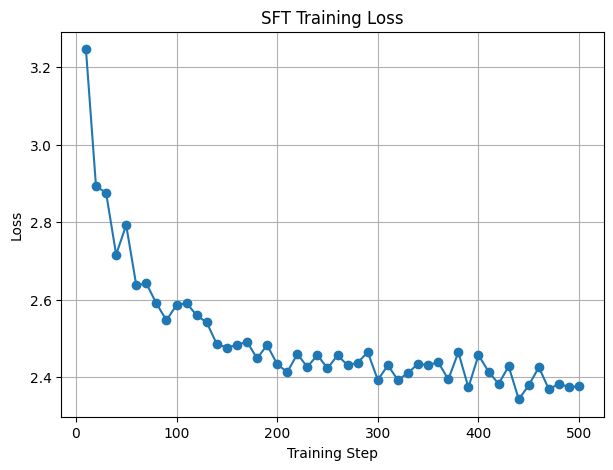

Final SFT Loss: 2.3769420623779296


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/distilgpt2-sft/tokenizer_config.json',
 '/content/drive/MyDrive/distilgpt2-sft/tokenizer.json')

In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments
from trl import SFTTrainer

model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

dataset_sft = load_dataset("tatsu-lab/alpaca", split="train")

def formatting_prompts_func(example):
    if example.get("input", "") != "":
        text = f"### Instruction:\n{example['instruction']}\n\n### Input:\n{example['input']}\n\n### Response:\n{example['output']}"
    else:
        text = f"### Instruction:\n{example['instruction']}\n\n### Response:\n{example['output']}"
    return text

training_args_sft = TrainingArguments(
    output_dir="/content/drive/MyDrive/sft_results",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    max_steps=500,
    logging_steps=10,
    save_steps=100,
    fp16=True,
    push_to_hub=False,
    report_to="none"
)

sft_trainer = SFTTrainer(
    model=model,
    train_dataset=dataset_sft,
    formatting_func=formatting_prompts_func,
    args=training_args_sft,
)

print("Starting SFT Training...")
sft_trainer.train()

import matplotlib.pyplot as plt

logs = sft_trainer.state.log_history

steps = []
losses = []

for log in logs:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

plt.figure(figsize=(7,5))
plt.plot(steps, losses, marker='o')

plt.title("SFT Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.grid(True)
plt.show()

print("Final SFT Loss:", losses[-1])

sft_model_path = "/content/drive/MyDrive/distilgpt2-sft"
sft_trainer.save_model(sft_model_path)
tokenizer.save_pretrained(sft_model_path)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/distilgpt2-sft
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Reward Model Training...


Step,Training Loss
10,0.809429
20,0.703041
30,0.663044
40,0.682101
50,0.667039
60,0.666600
70,0.669889
80,0.656365
90,0.648835
100,0.671480


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

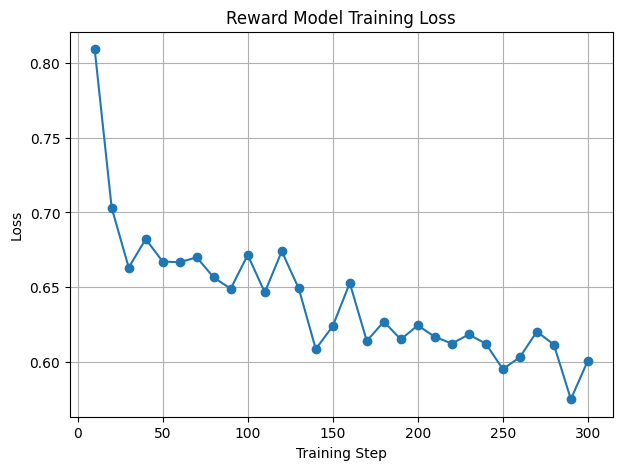

Final RM Loss: 0.600593900680542


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from trl import RewardTrainer, RewardConfig
from datasets import load_dataset

sft_model_path = "/content/drive/MyDrive/distilgpt2-sft"
tokenizer = AutoTokenizer.from_pretrained(sft_model_path)
tokenizer.pad_token = tokenizer.eos_token

rm_model = AutoModelForSequenceClassification.from_pretrained(
    sft_model_path,
    num_labels=1,
    device_map="auto"
)
rm_model.config.pad_token_id = tokenizer.pad_token_id

dataset_rm = load_dataset("Anthropic/hh-rlhf", split="train[:5000]")

def preprocess_function(examples):
    new_examples = {
        "input_ids_chosen": [],
        "attention_mask_chosen": [],
        "input_ids_rejected": [],
        "attention_mask_rejected": [],
    }
    for chosen, rejected in zip(examples["chosen"], examples["rejected"]):
        tokenized_chosen = tokenizer(chosen, truncation=True, max_length=512)
        tokenized_rejected = tokenizer(rejected, truncation=True, max_length=512)

        new_examples["input_ids_chosen"].append(tokenized_chosen["input_ids"])
        new_examples["attention_mask_chosen"].append(tokenized_chosen["attention_mask"])
        new_examples["input_ids_rejected"].append(tokenized_rejected["input_ids"])
        new_examples["attention_mask_rejected"].append(tokenized_rejected["attention_mask"])

    return new_examples

processed_dataset_rm = dataset_rm.map(preprocess_function, batched=True)

reward_config = RewardConfig(
    output_dir="/content/drive/MyDrive/rm_results",
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    learning_rate=1e-5,
    max_steps=300,
    logging_steps=10,
    fp16=True,
    report_to="none"
)

rm_trainer = RewardTrainer(
    model=rm_model,
    args=reward_config,
    train_dataset=processed_dataset_rm,
    processing_class=tokenizer
)

print("Starting Reward Model Training...")
rm_trainer.train()

import matplotlib.pyplot as plt

logs = rm_trainer.state.log_history

steps = []
losses = []

for log in logs:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

plt.figure(figsize=(7,5))
plt.plot(steps, losses, marker='o')

plt.title("Reward Model Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.grid(True)
plt.show()

print("Final RM Loss:", losses[-1])

rm_model_path = "/content/drive/MyDrive/distilgpt2-rm"
rm_trainer.save_model(rm_model_path)

In [ ]:
!pip install trl==0.11.0 -U

  Using cached trl-0.11.0-py3-none-any.whl.metadata (12 kB)
Using cached trl-0.11.0-py3-none-any.whl (316 kB)
  Attempting uninstall: trl
    Found existing installation: trl 1.3.0
    Uninstalling trl-1.3.0:
      Successfully uninstalled trl-1.3.0


In [ ]:
import torch
from tqdm import tqdm
from transformers import AutoTokenizer, pipeline
from trl import AutoModelForCausalLMWithValueHead, PPOConfig, PPOTrainer
from datasets import load_dataset

sft_model_path = "/content/drive/MyDrive/distilgpt2-sft"
rm_model_path = "/content/drive/MyDrive/distilgpt2-rm"

model = AutoModelForCausalLMWithValueHead.from_pretrained(sft_model_path).to("cuda")
ref_model = AutoModelForCausalLMWithValueHead.from_pretrained(sft_model_path).to("cuda")
tokenizer = AutoTokenizer.from_pretrained(sft_model_path)
tokenizer.pad_token = tokenizer.eos_token

reward_pipe = pipeline("text-classification", model=rm_model_path, device=0)

config = PPOConfig(
    model_name="distilgpt2-ppo",
    learning_rate=5e-6,
    batch_size=32,
    mini_batch_size=4,
    gradient_accumulation_steps=4,
    optimize_cuda_cache=True,
    target_kl=0.05,
    ppo_epochs=3
)

def build_dataset():
    ds = load_dataset("tatsu-lab/alpaca", split="train[:1000]")
    def tokenize(sample):
        prompt = f"### Instruction:\n{sample['instruction']}\n\n### Response:\n"
        sample["input_ids"] = tokenizer.encode(prompt, truncation=True, max_length=256)
        sample["query"] = prompt
        return sample
    return ds.map(tokenize, batched=False)

dataset = build_dataset()

def collator(data):
    return {key: [d[key] for d in data] for key in data[0]}

ppo_trainer = PPOTrainer(config, model, ref_model, tokenizer, dataset=dataset, data_collator=collator)

generation_kwargs = {
    "min_length": -1,
    "top_k": 0.0,
    "top_p": 0.9,
    "do_sample": True,
    "pad_token_id": tokenizer.eos_token_id,
    "max_new_tokens": 32,
}

print("Starting PPO Training...")
for batch in tqdm(ppo_trainer.dataloader):
    query_tensors = [torch.tensor(q).cuda() for q in batch["input_ids"]]

    response_tensors = ppo_trainer.generate(query_tensors, **generation_kwargs)
    batch["response"] = [tokenizer.decode(r.squeeze()) for r in response_tensors]

    texts = [q + r for q, r in zip(batch["query"], batch["response"])]
    pipe_outputs = reward_pipe(texts)
    rewards = [torch.tensor(output["score"]).cuda() for output in pipe_outputs]

    stats = ppo_trainer.step(query_tensors, response_tensors, rewards)
    ppo_trainer.log_stats(stats, batch, rewards)

model.save_pretrained("/content/drive/MyDrive/distilgpt2-rlhf")
print("PPO Training Complete! Model saved to /content/drive/MyDrive/distilgpt2-rlhf")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/77 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_config.py:207: FutureWarning: `PPOConfig` is deprecated and will be removed in the future. Please use `PPOv2Config` with `PPOv2Trainer` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:193: FutureWarning: `PPOTrainer` is deprecated and will be removed in trl v0.12. Please use `PPOv2Trainer` instead.
  warnings.warn(


Starting PPO Training...


  3%|▎         | 1/31 [00:06<03:22,  6.73s/it]/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -2.71 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
  6%|▋         | 2/31 [00:13<03:18,  6.83s/it]/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -3.70 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
 10%|▉         | 3/31 [00:21<03:24,  7.31s/it]/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL diver

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

PPO Training Complete! Model saved to /content/drive/MyDrive/distilgpt2-rlhf


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/distilgpt2-sft")
tokenizer.pad_token = tokenizer.eos_token

sft_model = AutoModelForCausalLM.from_pretrained("/content/drive/MyDrive/distilgpt2-sft").to("cuda")
rlhf_model = AutoModelForCausalLM.from_pretrained(
    "/content/drive/MyDrive/distilgpt2-rlhf",
    ignore_mismatched_sizes=True
).to("cuda")

def generate_comparison(model, prompt, max_len=128):
    full_prompt = f"### Instruction:\n{prompt}\n\n### Response:\n"
    inputs = tokenizer(full_prompt, return_tensors="pt", add_special_tokens=True).to("cuda")

    with torch.no_grad():
        output_tokens = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_len,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            temperature=0.8,
            top_p=0.95,
            use_cache=False
        )

    decoded = tokenizer.decode(output_tokens[0], skip_special_tokens=True)
    return decoded.split("### Response:")[-1].strip()

test_prompts = [
    "Give a tip for staying healthy.",
    "Explain what a solar eclipse is.",
    "Write a short greeting for a new neighbor."
]

for p in test_prompts:
    print(f"\n{'='*20} PROMPT: {p} {'='*20}")

    print("\n[SFT MODEL (Baseline)]")
    print(generate_comparison(sft_model, p))

    print("\n[RLHF MODEL (Aligned)]")
    print(generate_comparison(rlhf_model, p))
    print("-" * 80)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: /content/drive/MyDrive/distilgpt2-rlhf
Key                   | Status     |  | 
----------------------+------------+--+-
v_head.summary.bias   | UNEXPECTED |  | 
v_head.summary.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



==================== PROMPT: Give a tip for staying healthy. ====================

[SFT MODEL (Baseline)]
I'm always going to be a lot of healthy, healthy people. I'm constantly being mindful of my body and the health I enjoy. I'm always looking to get my body around my weight and feel good. I'm also constantly trying to keep my body in shape and stay motivated. I'll always try to get better at my workouts, so stay healthy and stay motivated.

[RLHF MODEL (Aligned)]
Going to bed is the most important thing to keep in mind, and staying healthy is definitely important for keeping your body hydrated. Additionally, staying hydrated is important for reducing stress and inflammation in your body.
--------------------------------------------------------------------------------

==================== PROMPT: Explain what a solar eclipse is. ====================

[SFT MODEL (Baseline)]
A solar eclipse is a very powerful event that occurs when a person is surrounded by millions of stars and a so

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/distilgpt2-sft")
tokenizer.pad_token = tokenizer.eos_token

sft_model = AutoModelForCausalLM.from_pretrained("/content/drive/MyDrive/distilgpt2-sft").to("cuda")
rlhf_model = AutoModelForCausalLM.from_pretrained(
    "/content/drive/MyDrive/distilgpt2-rlhf",
    ignore_mismatched_sizes=True
).to("cuda")

def generate_comparison(model, prompt, max_len=128):
    full_prompt = f"### Instruction:\n{prompt}\n\n### Response:\n"
    inputs = tokenizer(full_prompt, return_tensors="pt", add_special_tokens=True).to("cuda")

    with torch.no_grad():
        output_tokens = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_len,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True,
            temperature=0.8,
            top_p=0.95,
            use_cache=False
        )

    decoded = tokenizer.decode(output_tokens[0], skip_special_tokens=True)
    return decoded.split("### Response:")[-1].strip()

test_prompts = [
    "How do I bake a cake?"
]

for p in test_prompts:
    print(f"\n{'='*20} PROMPT: {p} {'='*20}")

    print("\n[SFT MODEL (Baseline)]")
    print(generate_comparison(sft_model, p))

    print("\n[RLHF MODEL (Aligned)]")
    print(generate_comparison(rlhf_model, p))
    print("-" * 80)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: /content/drive/MyDrive/distilgpt2-rlhf
Key                   | Status     |  | 
----------------------+------------+--+-
v_head.summary.bias   | UNEXPECTED |  | 
v_head.summary.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



==================== PROMPT: How do I bake a cake? ====================

[SFT MODEL (Baseline)]
A cake will be baked in a low pressure oven until it is golden brown and golden brown, about 5 minutes, and about 30 minutes.

[RLHF MODEL (Aligned)]
I bake a cake with a light chocolate chip butter and an omelette. I bake a cake with a light chocolate chip butter and a medium-high-fat coconut butter.

Instructions:
Add all the flour, sugar, and baking soda.

Mix the flour, coconut butter, and eggs in the cream of milk until the batter is lightly browned.

Once the cake is dry, place the cake in a food processor and whisk until smooth.
--------------------------------------------------------------------------------


In [ ]:
!pip install -q -U "transformers==4.49.0" "trl==0.9.4" "accelerate" "datasets" "bitsandbytes"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.7/226.7 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.2 MB/s eta 0:00:00


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Starting Manual DPO Alignment...
Step 0 | Loss: 2.2272
Step 10 | Loss: 9.6528
Step 20 | Loss: 2.2586
Step 30 | Loss: 0.6931
Step 40 | Loss: 4.0160


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DPO Model Saved Successfully!


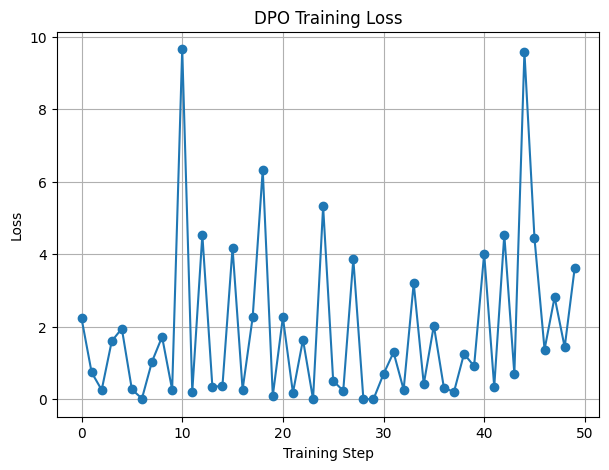

Final DPO Loss: 3.630094051361084


In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
from tqdm import tqdm

sft_model_path = "/content/drive/MyDrive/distilgpt2-sft"
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(sft_model_path)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(sft_model_path).to(device)
ref_model = AutoModelForCausalLM.from_pretrained(sft_model_path).to(device)
ref_model.eval()

dataset = load_dataset("trl-lib/ultrafeedback_binarized", split="train[:200]")

def get_batch_logps(logits, labels):
    labels = labels[:, 1:].clone()
    logits = logits[:, :-1, :]
    log_probs = F.log_softmax(logits, dim=-1)
    per_token_logps = torch.gather(log_probs, dim=2, index=labels.unsqueeze(2)).squeeze(2)
    return per_token_logps.sum(-1)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-7)
beta = 0.1

loss_history = []
step_history = []

print("Starting Manual DPO Alignment...")
model.train()

for i in range(50):
    item = dataset[i]

    try:
        prompt = item.get('prompt', "")
        chosen_txt = prompt + item['chosen'][-1]['content']
        rejected_txt = prompt + item['rejected'][-1]['content']
    except (KeyError, TypeError):
        prompt = item['prompt'] if 'prompt' in item else ""
        chosen_txt = prompt + item['chosen']
        rejected_txt = prompt + item['rejected']

    c_in = tokenizer(chosen_txt, return_tensors="pt", truncation=True, max_length=512).to(device)
    r_in = tokenizer(rejected_txt, return_tensors="pt", truncation=True, max_length=512).to(device)

    with torch.no_grad():
        ref_c_logp = get_batch_logps(ref_model(**c_in).logits, c_in["input_ids"])
        ref_r_logp = get_batch_logps(ref_model(**r_in).logits, r_in["input_ids"])

    policy_c_logp = get_batch_logps(model(**c_in).logits, c_in["input_ids"])
    policy_r_logp = get_batch_logps(model(**r_in).logits, r_in["input_ids"])

    loss = -F.logsigmoid(beta * ((policy_c_logp - policy_r_logp) - (ref_c_logp - ref_r_logp))).mean()

    loss.backward()
    loss_history.append(loss.item())
    step_history.append(i)
    optimizer.step()
    optimizer.zero_grad()

    if i % 10 == 0:
        print(f"Step {i} | Loss: {loss.item():.4f}")

model.save_pretrained("/content/drive/MyDrive/distilgpt2-dpo")
print("DPO Model Saved Successfully!")
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    step_history,
    loss_history,
    marker='o'
)

plt.title("DPO Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.grid(True)
plt.show()

print("Final DPO Loss:", loss_history[-1])

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/distilgpt2-sft")
tokenizer.pad_token = tokenizer.eos_token

sft_model = AutoModelForCausalLM.from_pretrained("/content/drive/MyDrive/distilgpt2-sft").to("cuda")
rlhf_model = AutoModelForCausalLM.from_pretrained("/content/drive/MyDrive/distilgpt2-rlhf").to("cuda")
dpo_model = AutoModelForCausalLM.from_pretrained("/content/drive/MyDrive/distilgpt2-dpo").to("cuda")

def generate_comparison(model, prompt, max_len=80):
    full_prompt = f"### Instruction:\n{prompt}\n\n### Response:\n"
    inputs = tokenizer(full_prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        output_tokens = model.generate(
            **inputs,
            max_new_tokens=max_len,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=True, temperature=0.8
        )
    return tokenizer.decode(output_tokens[0], skip_special_tokens=True).split("### Response:")[-1].strip()

test_prompts = [
    "Give a tip for staying healthy.",
    "Explain what a solar eclipse is.",
    "List instructions for baking a cake.",
    "Write a short greeting for a new neighbor."
]

for p in test_prompts:
    print(f"\nPROMPT: {p}")
    print(f"SFT: {generate_comparison(sft_model, p)}")
    print(f"PPO: {generate_comparison(rlhf_model, p)}")
    print(f"DPO: {generate_comparison(dpo_model, p)}")
    print("-" * 50)

OSError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/content/drive/MyDrive/distilgpt2-sft'. Use `repo_type` argument if needed.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/distilgpt2-sft")
tokenizer.pad_token = tokenizer.eos_token

models = {
    "SFT": AutoModelForCausalLM.from_pretrained("/content/drive/MyDrive/distilgpt2-sft").to(device),
    "RLHF": AutoModelForCausalLM.from_pretrained("/content/drive/MyDrive/distilgpt2-rlhf").to(device),
}

try:
    models["DPO"] = AutoModelForCausalLM.from_pretrained("/content/drive/MyDrive/distilgpt2-dpo").to(device)
except:
    print("No DPO model found, skipping...")

reward_pipe = pipeline("text-classification", model="/content/drive/MyDrive/distilgpt2-rm", device=0 if device=="cuda" else -1)

OSError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/content/drive/MyDrive/distilgpt2-sft'. Use `repo_type` argument if needed.

In [ ]:
def generate_response(model, prompt, max_len=100):
    full_prompt = f"### Instruction:\n{prompt}\n\n### Response:\n"
    inputs = tokenizer(full_prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_len,
            do_sample=True,
            temperature=0.8,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    return decoded.split("### Response:")[-1].strip()

In [ ]:
prompts = [
    "Explain what a solar eclipse is.",
    "Give a tip for staying healthy.",
    "List instructions for baking a cake.",
    "Write a short greeting for a new neighbor.",
    "What causes rain?",
    "Write a motivational quote.",
    "Explain photosynthesis.",
    "Give advice for time management.",
]

In [ ]:
results = {model_name: [] for model_name in models}

for prompt in tqdm(prompts):
    for model_name, model in models.items():
        output = generate_response(model, prompt)
        results[model_name].append(output)

NameError: name 'models' is not defined

In [ ]:
reward_scores = {model_name: [] for model_name in models}

for i, prompt in enumerate(prompts):
    for model_name in models:
        text = f"{prompt} {results[model_name][i]}"
        score = reward_pipe(text)[0]["score"]
        reward_scores[model_name].append(score)

avg_rewards = {m: np.mean(scores) for m, scores in reward_scores.items()}
std_rewards = {m: np.std(scores) for m, scores in reward_scores.items()}

print("Average Reward Scores:")
for m in avg_rewards:
    print(f"{m}: {avg_rewards[m]:.4f} ± {std_rewards[m]:.4f}")

Average Reward Scores:
SFT: 0.4592 ± 0.1502
RLHF: 0.6896 ± 0.1776
DPO: 0.5965 ± 0.1871


In [ ]:
def win_rate(model_a, model_b):
    wins = 0
    for i in range(len(prompts)):
        if reward_scores[model_a][i] > reward_scores[model_b][i]:
            wins += 1
    return wins / len(prompts)

print("\nWin Rates:")
for m1 in models:
    for m2 in models:
        if m1 != m2:
            print(f"{m1} beats {m2}: {win_rate(m1, m2)*100:.2f}%")


Win Rates:
SFT beats RLHF: 20.00%
SFT beats DPO: 30.00%
RLHF beats SFT: 80.00%
RLHF beats DPO: 70.00%
DPO beats SFT: 70.00%
DPO beats RLHF: 30.00%


In [ ]:
lengths = {
    model_name: [len(r.split()) for r in results[model_name]]
    for model_name in models
}

avg_lengths = {m: np.mean(l) for m, l in lengths.items()}

print("\nAverage Response Length:")
for m in avg_lengths:
    print(f"{m}: {avg_lengths[m]:.2f} words")


Average Response Length:
SFT: 35.80 words
RLHF: 47.90 words
DPO: 48.70 words


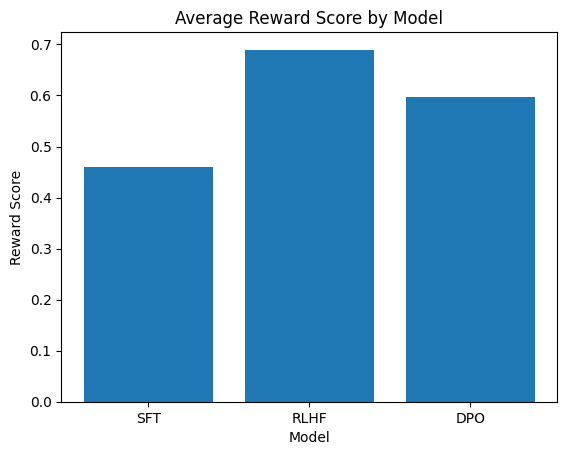

In [ ]:
plt.figure()
plt.bar(avg_rewards.keys(), avg_rewards.values())
plt.title("Average Reward Score by Model")
plt.xlabel("Model")
plt.ylabel("Reward Score")
plt.show()

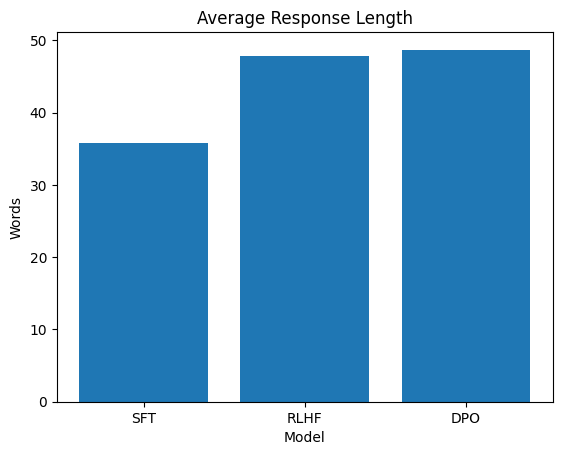

In [ ]:
plt.figure()
plt.bar(avg_lengths.keys(), avg_lengths.values())
plt.title("Average Response Length")
plt.xlabel("Model")
plt.ylabel("Words")
plt.show()

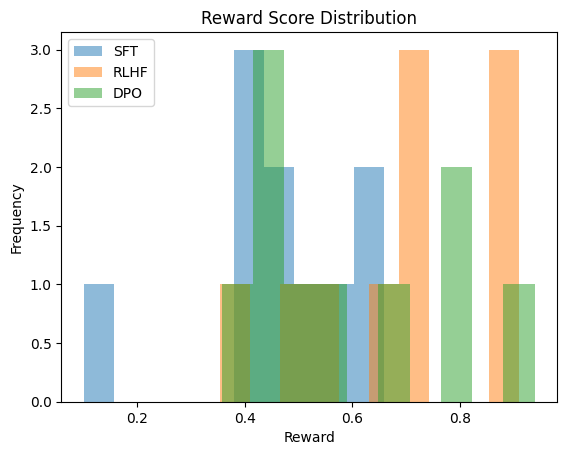

In [ ]:
plt.figure()
for model_name in reward_scores:
    plt.hist(reward_scores[model_name], alpha=0.5, label=model_name)

plt.legend()
plt.title("Reward Score Distribution")
plt.xlabel("Reward")
plt.ylabel("Frequency")
plt.show()

In [ ]:
for i, prompt in enumerate(prompts[:5]):  # show first 5
    print("\n" + "="*80)
    print(f"PROMPT: {prompt}")

    for model_name in models:
        print(f"\n[{model_name}]")
        print(results[model_name][i])


PROMPT: Explain what a solar eclipse is.

[SFT]
The sun is a colorful, bright, and bright glow that shines brightly on the sky. The sun is a powerful force on the Earth, and the sun is a powerful force on the planet.

[RLHF]
The sun is a bright, sunlike system that is a spectacular sight. It is surrounded by massive clouds, with wide-eyed eyes and wide-eyed eyes. The sun is lit up by the sun and is visible through a wide variety of shades of light.

[DPO]
The eclipse is usually caused by a meteorite

PROMPT: Give a tip for staying healthy.

[SFT]
1. Stay healthy.
2. Eat fruits, vegetables, and fruits.
3. Exercise and exercise regularly.
4. Eat healthy.
5. Practice mindfulness and relaxation.

[RLHF]
When you travel, it is important to be aware of your body type and your diet. You should be careful not to overeat, or even be too full.

[DPO]
Stay healthy and healthy is a good way to focus on your fitness goals and stay healthy. By staying healthy, your body will have the ability to imp

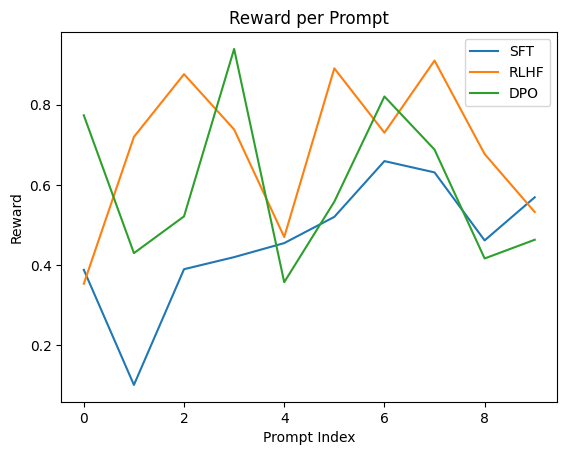

In [ ]:
plt.figure()
for model_name in reward_scores:
    plt.plot(reward_scores[model_name], label=model_name)

plt.legend()
plt.title("Reward per Prompt")
plt.xlabel("Prompt Index")
plt.ylabel("Reward")
plt.show()